In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
from pathlib import Path
from math import ceil
import socket
import scipy.signal as signal
import glob
import time
from random import randint
%matplotlib widget

In [2]:
# Path to get to /home/rfsoc
home_dir = Path("./../..")
os.chdir(home_dir)

# Paths relative to /home/rfsoc
primecam_readout = Path('./primecam_readout')
ccatkidlib = Path('./ccatkidlib')
data_dir = Path('/mnt/md0/')

# Append paths
sys.path.insert(0, os.path.abspath(ccatkidlib / 'rfsoc')) # Path contaning rfsoc_daq

In [3]:
%load_ext autoreload
%autoreload 2

import rfsoc_io

In [4]:
# Gather all vna timestamps
def all_timestamps(cfg_dir):
    all_timestamps = {'vna':[], 'targ':[], 'stream':[]}

    for cfg_file in np.sort(glob.glob(str(cfg_dir / "vna_config_ext_*.yaml"))):
        ctime = cfg_file.split('/vna_config_ext_')[1].split(".yaml")[0]
        all_timestamps['vna'].append(ctime)
    
    for cfg_file in np.sort(glob.glob(str(cfg_dir / "tar*_config_ext_*.yaml"))):
        ctime = cfg_file.split('config_ext_')[1].split(".yaml")[0]
        all_timestamps['targ'].append(ctime)
    
    for cfg_file in np.sort(glob.glob(str(cfg_dir / "timestream_config_ext_*.yaml"))):
        ctime = cfg_file.split('/timestream_config_ext_')[1].split(".yaml")[0]
        all_timestamps['stream'].append(ctime)
        
    return all_timestamps

def config_dir(date, sess_id, data_dir, data_name):
    io_cfg_name = f'init_config_io_{sess_id}.yaml'
    cfg_dir = data_dir / data_name / 'rfsoc' / date / sess_id
    return cfg_dir

In [5]:
#Gather all data for given timestamp

def collect_all_files(all_timestamps, cfg_dir, load_configs = False, vna_only = False, quickload = True):
    '''
    take a dictionary of all timestamps, groups all data, gathers the location of data and config files
    optionally loads all configs

    Takes a dictionary of all timestamps, and a config directory

    Returns dictionaries for vna, target sweep, and timestreams associated with timestamp. Within those dicts, the key data is:

    'ext_cfg': 'array_temp', 'coldload_temp', and 'power_supply_voltage'
    'dr_cfg': Need to specify drone (e.g. B1D1) but then you'll get
        'atten': attenuation set up
        'tones': 'NCLO', 'bandwidth', 'N_step', 'dB', 'num_tones', 'tone_freqs', 'tone_powers', 'tone_phis'
        'det_config': 'detector_type', 'nominal_num_detectors', 'nominal_detector_freqs', 'found_num_detectors', 'found_detector_freqs'
        'det_find': same argument options used in primecam_readout
    'data_files': the actual numpy files for loading
    '''

    Masterlist = {}
    
    #Groups all files
    keys = all_timestamps['vna']
    try:
        final = max([int(all_timestamps['targ'][-1]), int(all_timestamps['stream'][-1])]) +1
    except:
        final = max(int(keys)) + 1
    bookends = np.array([int(t) for t in keys[1:] + [final]])
    all_targs = np.array([int(t) for t in all_timestamps['targ']])
    all_streams = np.array([int(t) for t in all_timestamps['stream']])
    
    for key, bookend in zip(keys, bookends):
        targ_times = list(filter(lambda x: (x>=int(key))and(x<bookend), all_targs))
        stream_times = list(filter(lambda x: (x>=int(key))and(x<bookend), all_streams))
        vna_files = {'ext_file': load_cfgs(key, cfg_dir, files_only=True), 
                'dr_files': load_cfgs(key, cfg_dir, drone=True, files_only=True), 
                'data_files':grab_data_files(key, cfg_dir, 'vna')}
        key_dict = {'targ_times':targ_times ,'stream_times':stream_times, 'vna_files':vna_files}
        if load_configs:
            if quickload:
                vna_cfgs = {'ext_cfg': load_cfgs(key, cfg_dir), 'dr_cfg': load_cfgs(key, cfg_dir, drone=True)}
            else:
                vna_cfgs = {'ext_cfg': load_cfgs(key, cfg_dir), 'dr_cfg': load_cfgs(key, cfg_dir, drone=True, quickload=False)}
            key_dict['vna_cfgs']=vna_cfgs
        Masterlist[key]=key_dict

    if vna_only:
        return Masterlist
        
    #Setup file dictionaries and load configs
    for key in keys:
        targ_times = Masterlist[key]['targ_times']
        targ_dict = {}

        for targ_time in targ_times:
            targ_time = str(targ_time)
            targ_files = {'ext_file': load_cfgs(targ_time, cfg_dir, files_only=True), 
                'dr_files': load_cfgs(targ_time, cfg_dir, drone=True, files_only=True), 
                'data_files': grab_data_files(targ_time, cfg_dir, 'targ')}
            targ_dict[targ_time] = {'targ_files':targ_files}
            if load_configs:
                if quickload:
                    targ_cfgs = {'ext_cfg': load_cfgs(targ_time, cfg_dir), 'dr_cfg': load_cfgs(targ_time, cfg_dir, drone=True)}
                else:
                    targ_cfgs = {'ext_cfg': load_cfgs(targ_time, cfg_dir), 'dr_cfg': load_cfgs(targ_time, cfg_dir, drone=True, quickload=False)}
                targ_dict[targ_time]['targ_cfgs']=targ_cfgs 

        stream_times = Masterlist[key]['stream_times']
        stream_dict = {}

        for stream_time in stream_times:
            stream_time = str(stream_time)
            stream_files = {'ext_file': load_cfgs(stream_time, cfg_dir, files_only=True), 
                'dr_files': load_cfgs(stream_time, cfg_dir, drone=True, files_only=True), 
                'data_files': grab_data_files(stream_time, cfg_dir, 'timestream')}
            stream_dict[stream_time] = {'stream_files':stream_files}
            if load_configs:
                if quickload:
                    stream_cfgs = {'ext_cfg': load_cfgs(stream_time, cfg_dir), 'dr_cfg': load_cfgs(stream_time, cfg_dir, drone=True)}
                else:
                    stream_cfgs = {'ext_cfg': load_cfgs(stream_time, cfg_dir), 'dr_cfg': load_cfgs(stream_time, cfg_dir, drone=True, quickload=False)}
                stream_dict[stream_time]['stream_cfgs']=stream_cfgs 
        
        Masterlist[key]['targ_dict']=targ_dict
        Masterlist[key]['stream_dict']=stream_dict

                       
    return Masterlist

def load_cfgs(tstamp, cfg_dir, drone=False, files_only=False, quickload=True):
    '''
    Load config files, either drone or external
    '''
    if drone:
        io_cfg = rfsoc_io.load_config(glob.glob(str(cfg_dir / "init_config_io_*.yaml"))[0])
        drone_list = io_cfg['drone_list']

        drone_cfgs = {}

        for dnum in drone_list:
            bid, drid = dnum.split('.')
            dkey = f'B{bid}D{drid}'
            d_cfg_file = glob.glob(str(cfg_dir / dkey / f"*_config_drone_{tstamp}.yaml"))[0]
            if files_only:
                d_cfg = d_cfg_file
            elif quickload:
                d_cfg = quickload_dr_config(d_cfg_file) 
            else:
                d_cfg = rfsoc_io.load_config(d_cfg_file)
            drone_cfgs[dkey] = d_cfg
        return drone_cfgs
        
    ext_cfg_file = glob.glob(str(cfg_dir / f"*_config_ext_{tstamp}.yaml"))[0]
    if files_only:
        return ext_cfg_file
    ext_config = rfsoc_io.load_config(ext_cfg_file)
    return ext_config

def grab_data_files(tstamp, cfg_dir, key):
    '''
    Makes a dictionary of the data files of a particular type
    '''
    data_dir = str(cfg_dir).replace("/rfsoc/", "/" + key + "/")
    
    io_cfg = rfsoc_io.load_config(glob.glob(str(cfg_dir / "init_config_io_*.yaml"))[0])
    drone_list = io_cfg['drone_list']

    drone_data = {}
    
    for dnum in drone_list:
        bid, drid = dnum.split('.')
        dkey = f'B{bid}D{drid}'
        drone_dir = data_dir + "/" + dkey + "/"
        datafiles = glob.glob(drone_dir + f"*{tstamp}*")
        drone_data[dkey] = datafiles
    
    return drone_data

def quickload_dr_config(dr_file):
    '''
    Grabs a few key parameters from the file rather than the fully loading the config
    '''
    d_cfg = {}
    with open(dr_file, 'r') as f:
        for line in f.readlines():
            if 'atten' in line:
                dr = line.split("drive:")[1].split(",")[0]
                sn = line.split("sense:")[1].split("}")[0]
                d_cfg['atten'] = {"drive":dr, "sense":sn}
            elif 'found_num_detectors' in line:
                found = line.split("detectors:")[1]
                d_cfg['found_num_detectors'] = found
    return d_cfg

In [6]:
# Details for file names
data_name = 'modcam_coldload_data'
date = '20241209'
sess_id = '1733771373'

# Data Directory Name
cfg_dir = config_dir(date, sess_id, data_dir, data_name)

In [7]:
#Gather all time stamps and load the masterlist
timestamps = all_timestamps(cfg_dir)
Masterlist = collect_all_files(timestamps, cfg_dir, load_configs = True, vna_only = False, quickload= False)

In [8]:
#list all timestamps with temps and whether 
for key in Masterlist.keys():
    dc = Masterlist[key]
    clT = dc['vna_cfgs']['ext_cfg']['coldload_temp']
    arT = dc['vna_cfgs']['ext_cfg']['array_temp']
    targs = dc['targ_times']
    if len(targs)==0:
        targs = None
    streams = dc['stream_times']
    if len(streams)==0:
        streams = None
    
    print(key, "\tColdload:", clT, "\tArray:", round(arT[0],4), "\n\tTargs:", targs, "\tStreams:", streams )

1733772346 	Coldload: 78.459 	Array: 0.0844 
	Targs: None 	Streams: None
1733772489 	Coldload: 78.459 	Array: 0.0844 
	Targs: None 	Streams: None
1733772649 	Coldload: 78.498 	Array: 0.0844 
	Targs: None 	Streams: None
1733772806 	Coldload: 78.565 	Array: 0.0844 
	Targs: None 	Streams: None
1733772958 	Coldload: 78.563 	Array: 0.0844 
	Targs: None 	Streams: None
1733773113 	Coldload: 78.497 	Array: 0.0844 
	Targs: None 	Streams: None
1733773268 	Coldload: 78.456 	Array: 0.0843 
	Targs: None 	Streams: None
1733773422 	Coldload: 78.563 	Array: 0.0844 
	Targs: None 	Streams: None
1733773584 	Coldload: 78.526 	Array: 0.0843 
	Targs: None 	Streams: None
1733773729 	Coldload: 78.457 	Array: 0.0843 
	Targs: [1733774162, 1733774410] 	Streams: [1733774503]
1733774832 	Coldload: 78.453 	Array: 0.0844 
	Targs: [1733775265, 1733775512] 	Streams: [1733775605]


In [9]:
print(Masterlist[key].keys())

dict_keys(['targ_times', 'stream_times', 'vna_files', 'vna_cfgs', 'targ_dict', 'stream_dict'])


In [10]:
def plot_sweep(sweep_file, figax = None, label = "", n = 10, fix_offset=True, smooth = False, phase = False):
    # Create axes object or use passed axes object
    if figax is None:
        fig, ax = plt.subplots(figsize = (8, 8))
    else:
        fig, ax = figax
    
    fs, s21dB, s21_phase = prep_for_plot(sweep_file,n = n, fix_offset=fix_offset, phase = phase)
        
    if smooth:
        ax.plot(fs[n:]/1e6, signal.medfilt(s21dB, kernel_size = n)[n:], label = label)
    else:
        ax.plot(fs/1e6, s21dB, label = label)
    #ax.set_xlabel("Frequency (MHz)")
    #ax.set_ylabel("|S21| (dB)")

    # Create legend if label was provided
    if label != "":
        ax.legend(loc = 1)
        
    return fs, s21dB, s21_phase

def prep_for_plot(sweep_file,n = 10, fix_offset=True, phase = False):
    # Load VNA sweep data
    fs, s21z = np.load(sweep_file)
    fs = np.abs(fs) 
    s21m = np.abs(s21z)
    s21dB = 20*np.log10(s21m)#
    s21_phase = np.angle(s21z)

    if phase:
        s21dB = s21_phase
        fix_offset = False
        
    if fix_offset:
        offset = np.median(signal.medfilt(s21dB, kernel_size = n)[n:])
    else:
        offset = 0
        
    return fs, s21dB - offset, s21_phase 

# VNA style sweeps

No figures currently open


Text(0.5, 0.98, 'VNA Traces: Al network drone 2')

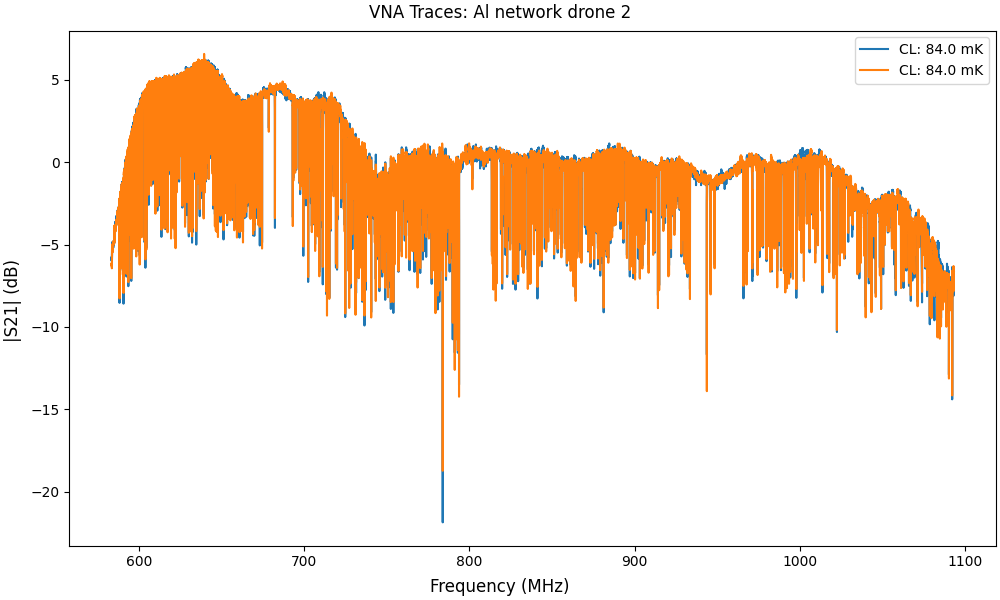

In [11]:
#Specify the attenuation target and the specific drone that you want to look at
att_target = 0
drone_target = 2

drone_key = f'B1D{drone_target}'

try:
    # Close the previous figure before creating a new one (otherwise they stay in memory)
    plt.close(fig_vna)
except:
    print("No figures currently open")

fig_vna, axes = plt.subplots(1, 1, figsize = (10, 6), constrained_layout = True)

for i, tstamp in enumerate(Masterlist.keys()):
    coldload_temp = float(Masterlist[tstamp]['vna_cfgs']['ext_cfg']['coldload_temp'])
    array_temps = float(np.array(Masterlist[tstamp]['vna_cfgs']['ext_cfg']['array_temp'])[0])*1000
    drive_atten = Masterlist[tstamp]['vna_cfgs']['dr_cfg'][drone_key]['atten']['drive']
    material = Masterlist[tstamp]['vna_cfgs']['dr_cfg'][drone_key]['det_config']['detector_type']

    if drive_atten == att_target:
        fname = Masterlist[tstamp]['vna_files']['data_files'][drone_key][0]
        fs, s21dB, s21_phase = plot_sweep(fname, figax = (fig_vna, axes), 
                                label = f'CL: {np.round(array_temps)} mK', n = 3, fix_offset=True)

fig_vna.supxlabel("Frequency (MHz)")
fig_vna.supylabel("|S21| (dB)")
fig_vna.suptitle(f"VNA Traces: {material} network drone {drone_target}")

# Target sweeps

No figures currently open


Text(0.5, 0.98, 'Target Traces: Al network drone 2')

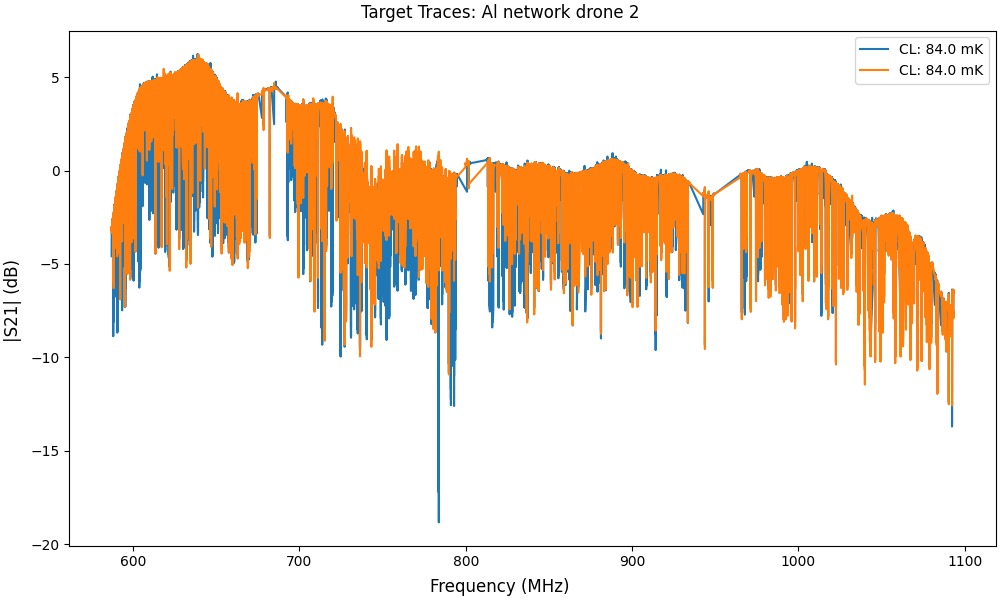

In [12]:
#Specify the attenuation target and the specific drone that you want to look at
att_target = 0
drone_target = 2

drone_key = f'B1D{drone_target}'

try:
    # Close the previous figure before creating a new one (otherwise they stay in memory)
    plt.close(fig_targ)
except:
    print("No figures currently open")

fig_targ, axes = plt.subplots(1, 1, figsize = (10, 6), constrained_layout = True)

for i, tstamp in enumerate(Masterlist.keys()):
    if len(Masterlist[tstamp]['targ_times'])>0:
        for targ_time in Masterlist[tstamp]['targ_dict'].keys():
            targ_dict = Masterlist[tstamp]['targ_dict'][targ_time]
            coldload_temp = float(targ_dict['targ_cfgs']['ext_cfg']['coldload_temp'])
            array_temps = float(np.array(targ_dict['targ_cfgs']['ext_cfg']['array_temp'])[0])*1000
            drive_atten = targ_dict['targ_cfgs']['dr_cfg'][drone_key]['atten']['drive']
            material = targ_dict['targ_cfgs']['dr_cfg'][drone_key]['det_config']['detector_type']
        
            if drive_atten == att_target:
                fname = targ_dict['targ_files']['data_files'][drone_key][0]
                fs, s21dB, s21_phase = plot_sweep(fname, figax = (fig_targ, axes), 
                                        label = f'CL: {np.round(array_temps)} mK', n = 3, fix_offset=True)

fig_targ.supxlabel("Frequency (MHz)")
fig_targ.supylabel("|S21| (dB)")
fig_targ.suptitle(f"Target Traces: {material} network drone {drone_target}")

# Timestream data

In [13]:
# List timestreams stamps and their masterlist keys
for tstamp in Masterlist.keys():
    if len(Masterlist[tstamp]['stream_times'])>0:
        print("key:", tstamp, "\n\tStream Times:", Masterlist[tstamp]['stream_times'],"\n\tTarget Times:", Masterlist[tstamp]['targ_times']) 

key: 1733773729 
	Stream Times: [1733774503] 
	Target Times: [1733774162, 1733774410]
key: 1733774832 
	Stream Times: [1733775605] 
	Target Times: [1733775265, 1733775512]


In [47]:
#First taking a random sample of a few detectors
drone_target = 2
drone_key = f'B1D{drone_target}'

#Timestamp for stream
key = '1733774832'
stream_time = '1733775605'
targ_time = '1733775512' # closest target time

#get initial data
stream_dict = Masterlist[key]['stream_dict'][stream_time]
found_det_freqs = np.array(stream_dict['stream_cfgs']['dr_cfg'][drone_key]['det_config']['found_detector_freqs'])

N = [randint(1, len(found_det_freqs)) for i in range(1)]

random_dets = found_det_freqs[N]

print(N)
    
array_temp = stream_dict['stream_cfgs']['ext_cfg']['array_temp'][0]
coldload_temp = stream_dict['stream_cfgs']['ext_cfg']['coldload_temp']
tone_power = stream_dict['stream_cfgs']['dr_cfg'][drone_key]['tones']['tone_powers'][0]
drive_atten = stream_dict['stream_cfgs']['dr_cfg'][drone_key]['atten']['drive']
tones = stream_dict['stream_cfgs']['dr_cfg'][drone_key]['tones']['tone_freqs']
'''found_det_freqs = np.array(stream_dict['stream_cfgs']['dr_cfg'][drone_key]['det_config']['found_detector_freqs'])
nearest_freqs = np.array([])
for samp_det in random_dets:
    near = np.where(np.abs(tones - samp_det)==np.min(np.abs(tones - samp_det)))
    nearest_freqs= np.append(nearest_freqs, found_det_freqs[near[0][0]])
'''
fnames = stream_dict['stream_files']['data_files'][drone_key]
print(random_dets)
#print(nearest_freqs)


[335]
[8.67818359e+08]


Text(0.5, 0.98, 'Noise Ball: drone 2, det_num: 335, Coldload: 78.5 K')

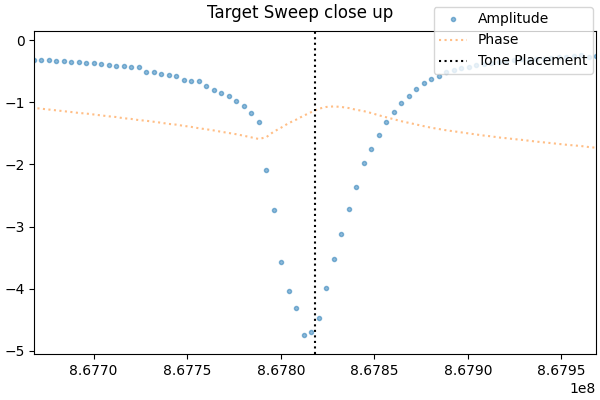

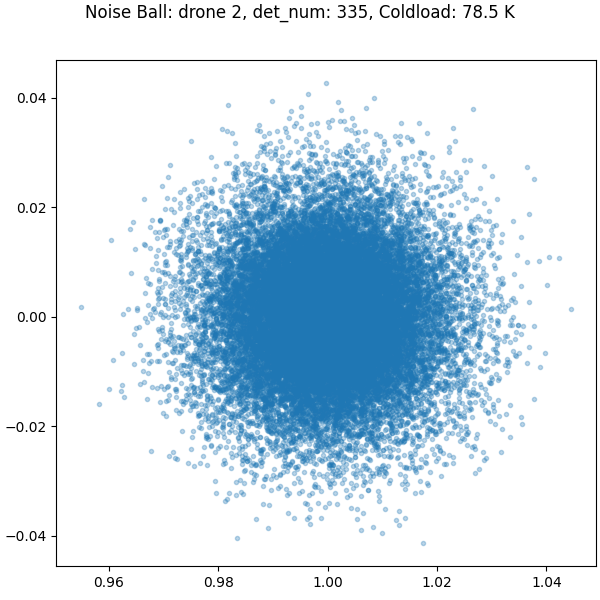

In [54]:
try:
    # Close the previous figure before creating a new one (otherwise they stay in memory)
    plt.close(fig_targ_closeup)
except:
    print("No figures currently open")

fig_targ_closeup, axes = plt.subplots(1, 1, figsize = (6, 4), constrained_layout = True)

#Plot the last target sweep.
targ_fname = Masterlist[key]['targ_dict'][targ_time]['targ_files']['data_files'][drone_key][0]

fs, s21dB, s21_phase = prep_for_plot(targ_fname, n = 1, fix_offset=True)
win_start, win_end = (N[0]*500,(N[0]+1)*500)
axes.plot(fs[win_start: win_end], s21dB[win_start: win_end], ".", alpha = 0.5, label = "Amplitude")
#axes.plot(fs[win_start+249], s21dB[win_start+249], "r*")
#axes.plot(fs[win_start+250], s21dB[win_start+250], "r*")
axes.plot(fs[win_start: win_end], np.unwrap(s21_phase[win_start: win_end]), ":", alpha = 0.5, label = "Phase")
axes.axvline(tones[N[0]], c="k", linestyle=":", label = "Tone Placement")
fig_targ_closeup.legend()
plt.gca().set_ylim(top = max([max(s21dB[win_start: win_end] + 0.25),max(s21_phase[win_start+220: win_end-220])]))
axes.set_xlim(max(fs[win_start], tones[N[0]] - 1.5e5), min(fs[win_end-1], tones[N[0]] +1.5e5))
fig_targ_closeup.suptitle("Target Sweep close up")

try:
    # Close the previous figure before creating a new one (otherwise they stay in memory)
    plt.close(fig_noise_IQ)
except:
    print("No figures currently open")

fig_noise_IQ, axes = plt.subplots(1, 1, figsize = (6, 6), constrained_layout = True)
plt.gca().set_aspect('equal')
    
for samp_tone in N:
    #Stitches together the timestreams from the various files
    noise_data = np.array([])
    for fname in fnames:
        data = np.load(fname)
        noise_data = np.append(noise_data, data[samp_tone])
        
    data = noise_data/noise_data.mean()
    axes.plot(data.real, data.imag, ".", alpha = 0.3, label = samp_tone)
#fig_noise.legend()
fig_noise_IQ.suptitle(f"Noise Ball: drone {drone_target}, det_num: {samp_tone}, Coldload: {np.round(coldload_temp,2)} K")

Text(0.5, 0.98, 'drone 2, Coldload: 78.5 K, det_num: 335')

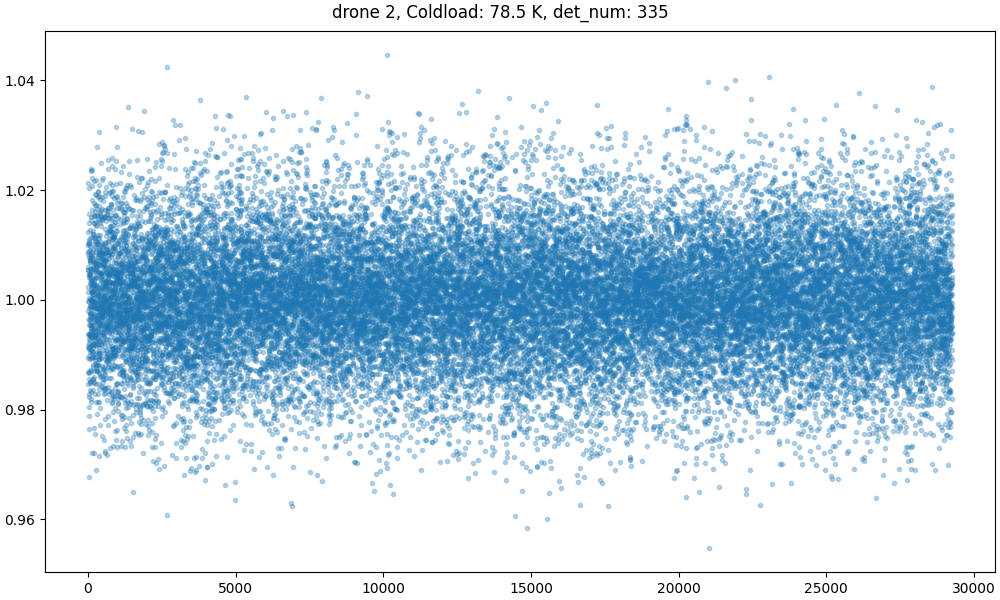

In [55]:
try:
    # Close the previous figure before creating a new one (otherwise they stay in memory)
    plt.close(fig_noise)
except:
    print("No figures currently open")

fig_noise, axes = plt.subplots(1, 1, figsize = (10, 6), constrained_layout = True)
    
for samp_tone in N:
    #Stitches together the timestreams from the various files
    noise_data = np.array([])
    for fname in fnames:
        data = np.load(fname)
        noise_data = np.append(noise_data, data[samp_tone])
        
    data = noise_data/noise_data.mean()
    axes.plot(np.abs(data), ".", alpha = 0.3)

fig_noise.suptitle(f"drone {drone_target}, Coldload: {np.round(coldload_temp,2)} K, det_num: {samp_tone}")